In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/Shareddrives/m5/"

calendar = pd.read_csv(DATA_PATH + "calendar.csv")
sell_prices = pd.read_csv(DATA_PATH + "sell_prices.csv")
sales = pd.read_csv(DATA_PATH + "sales_train_validation.csv")

In [ ]:
print("Calendar:", calendar.shape)
print("Sell Prices:", sell_prices.shape)
print("Sales:", sales.shape)

Calendar: (1969, 14)
Sell Prices: (6841121, 4)
Sales: (30490, 1919)


In [ ]:
for col in sales.columns:

    if sales[col].dtype == "float64":
        sales[col] = sales[col].astype("float32")

    if sales[col].dtype == "int64":
        sales[col] = sales[col].astype("int32")

In [ ]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [ ]:
sales.isnull().sum()

,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
...,...
d_1909,0
d_1910,0
d_1911,0
d_1912,0


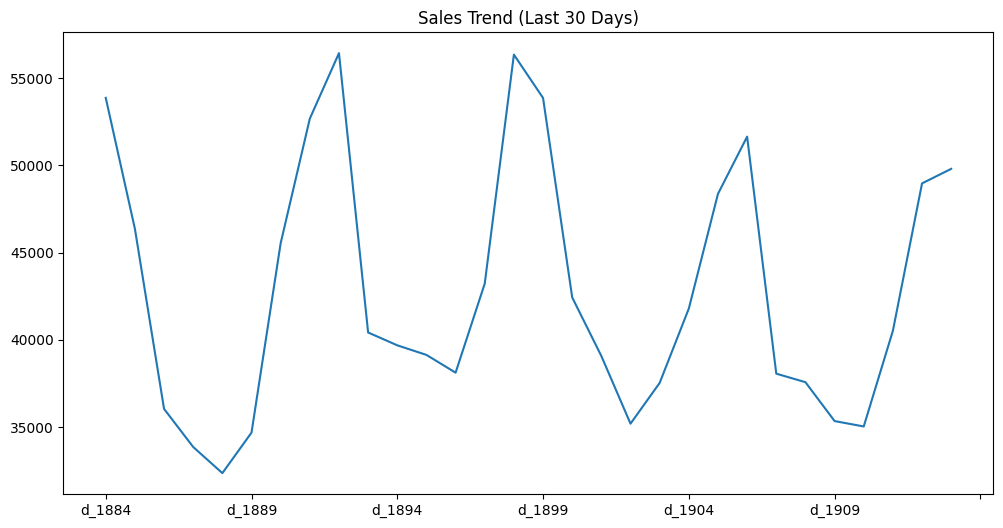

In [ ]:
sample = sales.iloc[:, -30:].sum()

plt.figure(figsize=(12,6))
sample.plot()
plt.title("Sales Trend (Last 30 Days)")
plt.show()

In [ ]:
sales_long = pd.melt(
    sales,
    id_vars=['id','item_id','dept_id','cat_id','store_id','state_id'],
    var_name='d',
    value_name='sales'
)

In [ ]:
sales_long.shape

(58327370, 8)

In [ ]:
data = pd.merge(
    sales_long,
    calendar,
    on="d",
    how="left"
)

In [ ]:
data = pd.merge(
    data,
    sell_prices,
    on=["store_id","item_id","wm_yr_wk"],
    how="left"
)

In [ ]:
data["date"] = pd.to_datetime(data["date"])

In [ ]:
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["week"] = data["date"].dt.isocalendar().week
data["day"] = data["date"].dt.day

In [ ]:
data["lag_7"] = data.groupby("id")["sales"].shift(7)
data["lag_14"] = data.groupby("id")["sales"].shift(14)
data["lag_21"] = data.groupby("id")["sales"].shift(21)
data["lag_28"] = data.groupby("id")["sales"].shift(28)
data["lag_56"] = data.groupby("id")["sales"].shift(56)

data["lag_365"] = data.groupby("id")["sales"].shift(365)

# Rolling stats
data["rmean_7"] = data.groupby("id")["sales"].transform(
    lambda x: x.shift(7).rolling(7).mean()
)

data["rmean_14"] = data.groupby("id")["sales"].transform(
    lambda x: x.shift(14).rolling(14).mean()
)


data["rmean_56"] = data.groupby("id")["sales"].transform(
    lambda x: x.shift(56).rolling(56).mean()
)

data["rmean_28"] = data.groupby("id")["sales"].transform(lambda x: x.shift(28).rolling(28).mean())
data["rstd_28"] = data.groupby("id")["sales"].transform(lambda x: x.shift(28).rolling(28).std())

# Momentum
data["momentum"] = data["lag_7"] / (data["lag_28"] + 1e-5)

# Price features
data["price_momentum"] = data["sell_price"] / data.groupby("id")["sell_price"].shift(1)
data["sales_diff"] = data["lag_7"] - data["lag_28"]

# Demand trend
data["rolling_trend"] = data["rmean_7"] / (data["rmean_28"] + 1e-5)
data["price_roll_mean_7"] = data.groupby("id")["sell_price"].transform(
    lambda x: x.shift(1).rolling(7).mean()
)

In [ ]:
data["price_change"] = data.groupby("id")["sell_price"].pct_change()

data["price_max"] = data.groupby("id")["sell_price"].transform("max")

data["price_norm"] = data["sell_price"] / data["price_max"]

In [ ]:
cat_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

for col in cat_cols:
    data[col] = data[col].astype("category")

In [ ]:
features = [
"item_id",
"dept_id",
"cat_id",
"store_id",
"state_id",

"sell_price",
"price_change",
"price_norm",

"year",
"month",
"week",
"day",

"lag_7",
"lag_14",
"lag_21",
"lag_28",
"lag_56",

"rmean_7",
"rmean_14",
"rmean_28",
"rmean_56",

"rstd_28",
"lag_365",
"momentum",
"price_momentum",
"rolling_trend",

"event_name_1",
"event_type_1",
"event_name_2",
"event_type_2",

"snap_CA",
"snap_TX",
"snap_WI",

"price_roll_mean_7",
"sales_diff",
]

In [ ]:
print(data.columns)

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'week', 'day', 'lag_7',
       'lag_14', 'lag_21', 'lag_28', 'lag_56', 'lag_365', 'rmean_7',
       'rmean_14', 'rmean_56', 'rmean_28', 'rstd_28', 'momentum',
       'price_momentum', 'sales_diff', 'rolling_trend', 'price_roll_mean_7',
       'price_change', 'price_max', 'price_norm'],
      dtype='object')


In [ ]:
data = data.dropna(subset=[
    "lag_7","lag_14","lag_21","lag_28","lag_56","lag_365",
    "rmean_7","rmean_14","rmean_28","rmean_56","rstd_28",
    "momentum","price_momentum","rolling_trend",
    "price_change","price_norm","price_roll_mean_7"
])

In [ ]:
print("Data shape:", data.shape)

Data shape: (40352373, 43)


In [ ]:
print(data.columns)

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'week', 'day', 'lag_7',
       'lag_14', 'lag_21', 'lag_28', 'lag_56', 'lag_365', 'rmean_7',
       'rmean_14', 'rmean_56', 'rmean_28', 'rstd_28', 'momentum',
       'price_momentum', 'sales_diff', 'rolling_trend', 'price_roll_mean_7',
       'price_change', 'price_max', 'price_norm'],
      dtype='object')


In [ ]:
split_date = data["date"].max() - pd.Timedelta(days=28)

train = data[data["date"] <= split_date]
valid = data[data["date"] > split_date]

In [ ]:
X_train = train[features]
y_train = np.log1p(train["sales"])

X_valid = valid[features]
y_valid = np.log1p(valid["sales"])

In [ ]:
train_data = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=cat_cols
)

valid_data = lgb.Dataset(
    X_valid,
    label=y_valid,
    categorical_feature=cat_cols
)

In [ ]:
params = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.1,
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 1024,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.1,   # NEW
    "lambda_l2": 0.1,
    "verbosity": -1
}

In [ ]:
print("Train shape:", train.shape)
print("Valid shape:", valid.shape)

Train shape: (39498653, 43)
Valid shape: (853720, 43)


In [ ]:
print("Train rows:", len(X_train))
print("Valid rows:", len(X_valid))

Train rows: 39498653
Valid rows: 853720


In [ ]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (39498653, 35)
X_valid: (853720, 35)


In [ ]:
missing = [f for f in features if f not in data.columns]
print("Missing:", missing)

Missing: []


In [ ]:
model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=3500,
    callbacks=[
        lgb.early_stopping(300),
        lgb.log_evaluation(100)
    ]
)

Training until validation scores don't improve for 300 rounds
[100]	valid_0's rmse: 0.489179
[200]	valid_0's rmse: 0.48741
[300]	valid_0's rmse: 0.487644
[400]	valid_0's rmse: 0.488045
Early stopping, best iteration is:
[184]	valid_0's rmse: 0.487358


In [ ]:
preds = model.predict(X_valid)
preds = np.expm1(preds)

In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(np.expm1(y_valid), preds))
print("RMSE:", rmse)

RMSE: 2.15327305364286


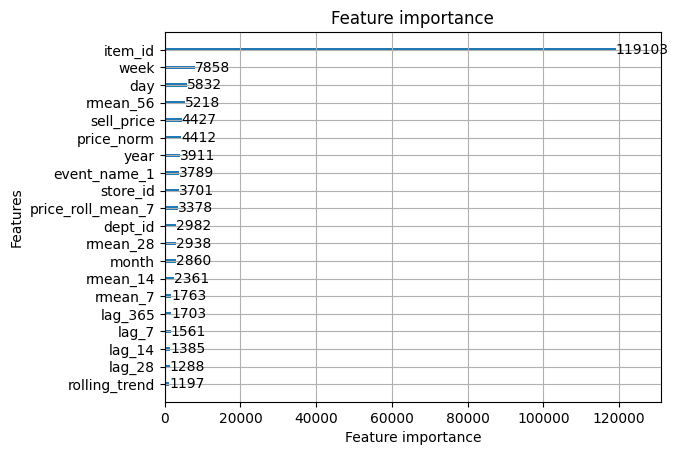

In [ ]:
lgb.plot_importance(model, max_num_features=20)
plt.show()

In [ ]:
# Compute RMSSE for each item
def rmsse(train_series, valid_series, preds):

    numerator = np.mean((valid_series - preds) ** 2)

    denominator = np.mean(np.diff(train_series) ** 2)

    return np.sqrt(numerator / denominator)

In [ ]:
valid["preds"] = preds

In [ ]:
# Step 1: Compute scale (denominator)
def compute_scale(train_df):
    scales = {}
    for item, grp in train_df.groupby("id"):
        series = grp["sales"].values
        diff = np.diff(series)
        scale = np.mean(diff ** 2)
        scales[item] = scale if scale != 0 else 1
    return scales


# Step 2: Compute weights (last 28 days revenue)
def compute_weights(train_df):
    last_28 = train_df.sort_values("date").groupby("id").tail(28)
    last_28["revenue"] = last_28["sales"] * last_28["sell_price"]
    weights = last_28.groupby("id")["revenue"].sum()
    weights = weights / weights.sum()
    return weights.to_dict()


# Step 3: WRMSSE
def compute_wrmsse(train_df, valid_df, preds):

    scales = compute_scale(train_df)
    weights = compute_weights(train_df)

    valid_df = valid_df.copy()
    valid_df["preds"] = preds

    wrmsse = 0

    for item, grp in valid_df.groupby("id"):
        y_true = grp["sales"].values
        y_pred = grp["preds"].values

        mse = np.mean((y_true - y_pred) ** 2)
        rmsse = np.sqrt(mse / scales[item])

        wrmsse += weights.get(item, 0) * rmsse

    return wrmsse


# Run it
wrmsse = compute_wrmsse(train, valid, preds)
print("WRMSSE:", wrmsse)

WRMSSE: 0.8610534904160445
